# Salary Range Prediction — NYC Jobs Postings
**Author:** Siddhant Varma
**Goal:** Predict the minimum and maximum salary (`Salary Range From` and `Salary Range To`) for a job posting, using the attributes of the posting itself — agency, title, category, career level, etc.



> **A note on the data before you run this.** The dataset used here (NYC job postings, including salary ranges) is not included in this repository. It was provided as part of a client project with terms that don't allow redistributing their copy of it — but the same dataset is genuinely public data, published by NYC Open Data. You can download an equivalent file yourself from https://data.cityofnewyork.us/d/kpav-sd4t (CSV export), save it as `data/raw/Jobs_NYC_Postings.csv`, and every cell below will run exactly as written. See `data/README.md` for details.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

## 1. Loading the data

The dataset is the NYC Jobs Postings file provided with the project brief, along with a data dictionary explaining each column.

In [9]:
df = pd.read_csv('../data/raw/Jobs_NYC_Postings.csv')
print(df.shape)
df.head(3)

(2795, 30)


,Job ID,Agency,Posting Type,# Of Positions,Business Title,Civil Service Title,Title Classification,Title Code No,Level,Job Category,Full-Time/Part-Time indicator,Career Level,Salary Range From,Salary Range To,Salary Frequency,Work Location,Division/Work Unit,Job Description,Minimum Qual Requirements,Preferred Skills,Additional Information,To Apply,Hours/Shift,Work Location 1,Recruitment Contact,Residency Requirement,Posting Date,Post Until,Posting Updated,Process Date
0,791249,OFFICE OF CRIMINAL JUSTICE,External,1,"Supervising Attorney for Operations, Assigned ...",EXECUTIVE AGENCY COUNSEL,Non-Competitive-5,95005,M1,Legal Affairs,F,Manager,68213.0,180000.0,Annual,253 Broadway New York Ny,ACP Staff,ABOUT THE OFFICE: THE OFFICE OF THE ASSIGNED...,Admission to the New York State Bar; and four ...,•\tExperience in negotiating and drafting gove...,NaN,NaN,NaN,253 Broadway New York Ny,NaN,New York City Residency is not required for th...,08/10/2026,09-OCT-2026,08/10/2026,09/21/2026
1,784279,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Early Childhood Education Consultant, Bureau o...",CONSULTANT (EARLY CHILDHOOD ED,Competitive-1,51611,01,Health,F,Experienced (non-manager),77211.0,77211.0,Annual,NYC - All Boroughs,Child Care,The Bureau of Child Care ensures that child ca...,1. A masters degree in education from an accre...,NaN,NaN,NaN,NaN,NYC - All Boroughs,NaN,New York City residency is generally required ...,09/15/2026,14-NOV-2026,09/15/2026,09/21/2026
2,798533,OFFICE OF MANAGEMENT & BUDGET,External,1,COLLEGE AIDE Budget,COLLEGE AIDE (ALL CITY DEPTS),Non-Competitive-5,10209,01,"Finance, Accounting, & Procurement Policy, Res...",P,Student,17.5,20.0,Hourly,255 Greenwich Street,Interns/Hourly Employees,TASK FORCE: \t\tEnvironmental Sustainability a...,For Assignment Level I: Matriculation at an a...,NaN,NaN,NaN,NaN,255 Greenwich Street,NaN,New York City residency is generally required ...,09/04/2026,03-NOV-2026,09/08/2026,09/21/2026


A quick look at the dtypes and how much is missing tells us where the pain points are going to be.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2795 entries, 0 to 2794
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Job ID                         2795 non-null   int64  
 1   Agency                         2795 non-null   object 
 2   Posting Type                   2795 non-null   object 
 3   # Of Positions                 2795 non-null   int64  
 4   Business Title                 2795 non-null   object 
 5   Civil Service Title            2795 non-null   object 
 6   Title Classification           2795 non-null   object 
 7   Title Code No                  2795 non-null   object 
 8   Level                          2795 non-null   object 
 9   Job Category                   2795 non-null   object 
 10  Full-Time/Part-Time indicator  2795 non-null   object 
 11  Career Level                   2795 non-null   object 
 12  Salary Range From              2795 non-null   f

In [11]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

Recruitment Contact          2795
Hours/Shift                  2462
Additional Information       1931
To Apply                     1609
Preferred Skills             1215
Post Until                     39
Minimum Qual Requirements      36
dtype: int64

Most of that missingness is in fields I'm not planning to use directly for modelling anyway (`Recruitment Contact`, `Post Until`, `Work Location 1`, `Hours/Shift`). The columns that actually matter for prediction — agency, title, category, career level, salary itself — are essentially complete. Good starting point.

## 2. The two problems this dataset is known for

Before touching anything, I checked for the two issues the project brief hinted at:

1. **Duplicate `Job ID`s** — the same posting can appear more than once (e.g. reposted internally and externally).
2. **Mixed `Salary Frequency`** — salaries are listed as Annual, Hourly, or Daily, all mixed into the same two numeric columns. Comparing a $22/hour posting to a $90,000/year posting directly would be meaningless.

In [12]:
print("Duplicate Job IDs:", df['Job ID'].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())
print()
print(df['Salary Frequency'].value_counts())

Duplicate Job IDs: 1348
Fully duplicate rows: 15

Salary Frequency
Annual    2578
Hourly     191
Daily       26
Name: count, dtype: int64


Let's check whether the salary values actually differ across duplicated Job IDs, or whether it's just the same posting repeated (internal vs. external, for instance).

In [13]:
dupe_check = df.groupby('Job ID')[['Salary Range From', 'Salary Range To']].nunique()
print("Job IDs where 'From' varies across duplicates:", (dupe_check['Salary Range From'] > 1).sum())
print("Job IDs where 'To' varies across duplicates:", (dupe_check['Salary Range To'] > 1).sum())

Job IDs where 'From' varies across duplicates: 0
Job IDs where 'To' varies across duplicates: 0


Zero variation — so these are genuine repeats of the same posting, not conflicting records. Safe to drop, keeping the first occurrence of each `Job ID`.

In [14]:
df = df.drop_duplicates(subset='Job ID', keep='first').reset_index(drop=True)
print("Shape after de-duplication:", df.shape)

Shape after de-duplication: (1447, 30)


## 3. Normalising salary to a single, comparable unit

I'm converting every salary to an **annualised** figure using standard, defensible conversions:

- **Hourly** → `hourly rate × 40 hours/week × 52 weeks`
- **Daily** → `daily rate × 5 days/week × 52 weeks`
- **Annual** → left as-is

This isn't manipulating the data — it's putting it on one consistent scale so the model is comparing like with like, which is the only way salary values across frequencies can be meaningfully combined for a single prediction target.

In [15]:
def annualise(row, col):
    value = row[col]
    freq = row['Salary Frequency']
    if freq == 'Hourly':
        return value * 40 * 52
    elif freq == 'Daily':
        return value * 5 * 52
    return value

df['Salary From Annual'] = df.apply(lambda r: annualise(r, 'Salary Range From'), axis=1)
df['Salary To Annual'] = df.apply(lambda r: annualise(r, 'Salary Range To'), axis=1)

df[['Salary Frequency', 'Salary Range From', 'Salary Range To', 'Salary From Annual', 'Salary To Annual']].sample(6, random_state=1)

,Salary Frequency,Salary Range From,Salary Range To,Salary From Annual,Salary To Annual
1198,Annual,84865.0,97595.0,84865.0,97595.0
529,Annual,54799.0,63019.0,54799.0,63019.0
1296,Annual,146843.0,146843.0,146843.0,146843.0
589,Annual,62868.0,97593.0,62868.0,97593.0
37,Annual,68213.0,115000.0,68213.0,115000.0
724,Annual,62868.0,72298.0,62868.0,72298.0


One more sanity check before moving on — a handful of postings had a `Salary Range From` of literally 0, which isn't a real salary floor, it's a data entry gap. There were 23 of them, all under the Annual frequency. I'm dropping those rather than imputing, since guessing a floor for them would be fabricating information the dataset doesn't have.

In [16]:
zero_salary = (df['Salary From Annual'] < 1000).sum()
print(f"Rows with an unusable (near-zero) starting salary: {zero_salary}")

df = df[df['Salary From Annual'] >= 1000].reset_index(drop=True)
print("Shape after removing them:", df.shape)

# and just to be safe — check no row has From > To after annualising
print("Rows where From > To:", (df['Salary From Annual'] > df['Salary To Annual']).sum())

Rows with an unusable (near-zero) starting salary: 0
Shape after removing them: (1447, 32)
Rows where From > To: 0


## 4. A look at the salary distribution

Before building any features, it helps to actually see what we're trying to predict.

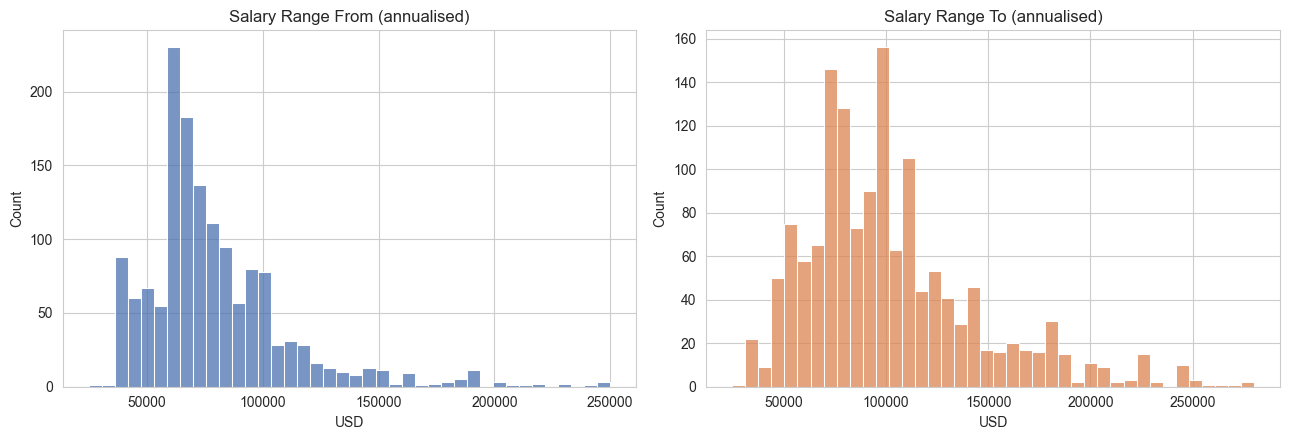

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['Salary From Annual'], bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('Salary Range From (annualised)')
axes[0].set_xlabel('USD')

sns.histplot(df['Salary To Annual'], bins=40, ax=axes[1], color='#DD8452')
axes[1].set_title('Salary Range To (annualised)')
axes[1].set_xlabel('USD')
plt.tight_layout()
plt.show()

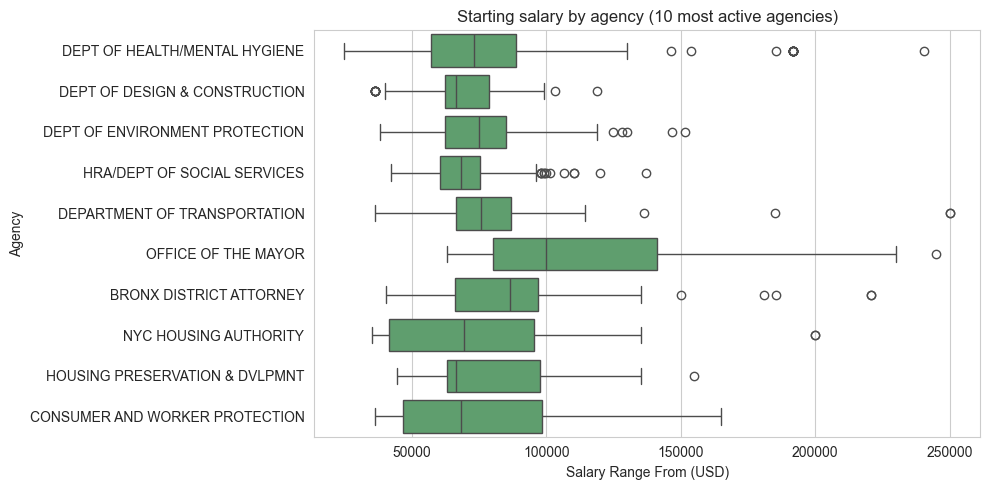

In [18]:
top_agencies = df['Agency'].value_counts().head(10).index
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df[df['Agency'].isin(top_agencies)],
    y='Agency', x='Salary From Annual', order=top_agencies, color='#55A868'
)
plt.title('Starting salary by agency (10 most active agencies)')
plt.xlabel('Salary Range From (USD)')
plt.tight_layout()
plt.show()

Pay clearly shifts by agency and, unsurprisingly, by career level too — worth confirming before I lean on these as model features.

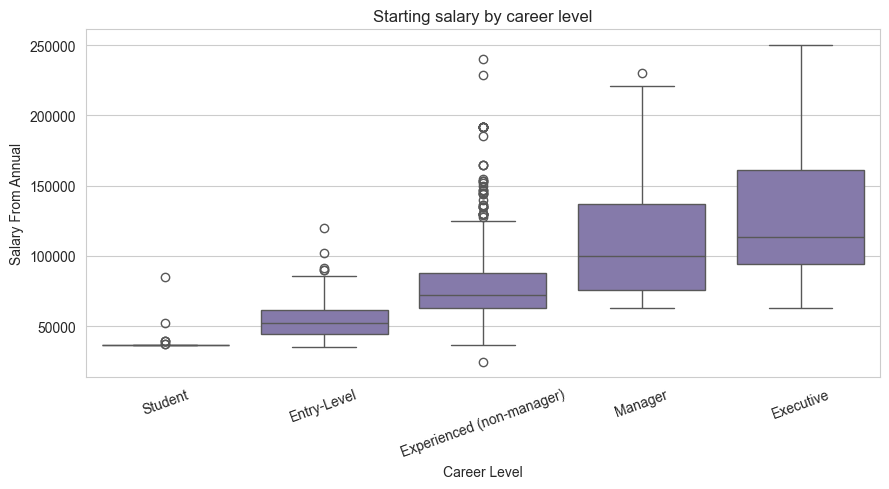

In [19]:
order = ['Student', 'Entry-Level', 'Experienced (non-manager)', 'Manager', 'Executive']
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Career Level', y='Salary From Annual', order=order, color='#8172B2')
plt.xticks(rotation=20)
plt.title('Starting salary by career level')
plt.tight_layout()
plt.show()

## 5. Feature engineering

I'm keeping the feature set close to what the project brief actually asked for — title, category, and location-type attributes — plus a few cheap-to-compute signals from the free-text fields that tend to correlate with seniority (longer job descriptions and requirement lists usually mean more senior, better-paid roles).

**Categorical features:** Agency, Posting Type, Job Category, Full-Time/Part-Time indicator, Career Level, Level, Title Classification, Civil Service Title.

**Numeric features:** number of positions, job-description word count, qualifications word count, whether preferred skills were listed, posting month.

`Work Location` and `Division/Work Unit` were too fragmented (hundreds of near-unique free-text values with no clean grouping) to be useful without a lot of manual mapping, so I left them out rather than force a noisy feature into the model.

In [20]:
df['Job Description'] = df['Job Description'].fillna('')
df['Minimum Qual Requirements'] = df['Minimum Qual Requirements'].fillna('')
df['Preferred Skills'] = df['Preferred Skills'].fillna('')

df['desc_word_count'] = df['Job Description'].str.split().str.len()
df['qual_word_count'] = df['Minimum Qual Requirements'].str.split().str.len()
df['has_preferred_skills'] = (df['Preferred Skills'].str.len() > 0).astype(int)

df['Posting Date'] = pd.to_datetime(df['Posting Date'], errors='coerce')
df['posting_month'] = df['Posting Date'].dt.month
df['posting_month'] = df['posting_month'].fillna(df['posting_month'].median())

cat_cols = ['Agency', 'Posting Type', 'Job Category', 'Full-Time/Part-Time indicator',
            'Career Level', 'Level', 'Title Classification', 'Civil Service Title']
num_cols = ['# Of Positions', 'desc_word_count', 'qual_word_count', 'has_preferred_skills', 'posting_month']
target_cols = ['Salary From Annual', 'Salary To Annual']

for c in cat_cols:
    df[c] = df[c].fillna('Unknown').astype(str)

df[cat_cols + num_cols + target_cols].head(3)

,Agency,Posting Type,Job Category,Full-Time/Part-Time indicator,Career Level,Level,Title Classification,Civil Service Title,# Of Positions,desc_word_count,qual_word_count,has_preferred_skills,posting_month,Salary From Annual,Salary To Annual
0,OFFICE OF CRIMINAL JUSTICE,External,Legal Affairs,F,Manager,M1,Non-Competitive-5,EXECUTIVE AGENCY COUNSEL,1,494,71,1,8,68213.0,180000.0
1,DEPT OF HEALTH/MENTAL HYGIENE,External,Health,F,Experienced (non-manager),01,Competitive-1,CONSULTANT (EARLY CHILDHOOD ED,1,729,286,0,9,77211.0,77211.0
2,OFFICE OF MANAGEMENT & BUDGET,External,"Finance, Accounting, & Procurement Policy, Res...",P,Student,01,Non-Competitive-5,COLLEGE AIDE (ALL CITY DEPTS),1,750,225,0,9,36400.0,41600.0


This cleaned, feature-ready table is what I'm saving as the processed dataset, and it's what the model actually trains on.

In [21]:
df.to_csv('../data/processed/jobs_cleaned.csv', index=False)
print("Saved processed dataset:", df.shape)

Saved processed dataset: (1447, 36)


## 6. Encoding the categorical features

`Civil Service Title` alone has close to 350 distinct values, and `Job Category` has over 150 — one-hot encoding either would blow the feature space up without adding much signal. Instead I'm using **target encoding**: each category gets replaced with the (smoothed) average salary midpoint for postings in that category.

To avoid leaking test information into the training encodings, I compute this with **out-of-fold encoding on the training set only** (5-fold), and apply the training-set averages to the test set. Smoothing pulls rare categories toward the global average so a title that only appears once or twice doesn't get an unstable estimate.

In [22]:
from sklearn.model_selection import train_test_split, KFold

df['midpoint'] = (df['Salary From Annual'] + df['Salary To Annual']) / 2

X = df[cat_cols + num_cols].copy()
y = df[target_cols].copy()
mid = df['midpoint'].copy()

X_train, X_test, y_train, y_test, mid_train, mid_test = train_test_split(
    X, y, mid, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)

Train shape: (1157, 13)  | Test shape: (290, 13)


In [23]:
def kfold_target_encode(X_train, mid_train, X_test, cols, n_splits=5, smoothing=10):
    global_mean = mid_train.mean()
    X_train_enc, X_test_enc = X_train.copy(), X_test.copy()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for col in cols:
        oof = np.zeros(len(X_train))
        for tr_idx, val_idx in kf.split(X_train):
            tr_x, val_x = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            tr_y = mid_train.iloc[tr_idx]
            stats = tr_y.groupby(tr_x[col]).agg(['mean', 'count'])
            smoothed = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
            oof[val_idx] = val_x[col].map(smoothed).fillna(global_mean).values
        X_train_enc[col + '_te'] = oof

        stats_full = mid_train.groupby(X_train[col]).agg(['mean', 'count'])
        smoothed_full = (stats_full['mean'] * stats_full['count'] + global_mean * smoothing) / (stats_full['count'] + smoothing)
        X_test_enc[col + '_te'] = X_test[col].map(smoothed_full).fillna(global_mean).values

        X_train_enc.drop(columns=[col], inplace=True)
        X_test_enc.drop(columns=[col], inplace=True)

    return X_train_enc, X_test_enc

X_train_enc, X_test_enc = kfold_target_encode(X_train, mid_train, X_test, cat_cols)
X_train_enc.head(3)

,# Of Positions,desc_word_count,qual_word_count,has_preferred_skills,posting_month,Agency_te,Posting Type_te,Job Category_te,Full-Time/Part-Time indicator_te,Career Level_te,Level_te,Title Classification_te,Civil Service Title_te
478,1,349,133,1,9,90023.476675,92775.860000,90023.476675,91541.111973,88346.810684,85302.158370,87227.849622,90023.476675
1432,1,408,145,1,8,83902.170371,88150.487637,88928.099802,90403.103066,87357.589694,86085.091715,87705.593817,91479.233339
380,1,1072,145,0,9,97739.001334,87788.332949,79071.466051,90705.708801,66206.252885,84752.511051,87993.749536,84805.313896


## 7. Trying a few candidate models

Rather than committing to one algorithm upfront, I ran five reasonable candidates — a linear baseline (Ridge) up through tree ensembles and gradient boosting — and compared them on the same held-out test set. Both salary targets are predicted jointly using `MultiOutputRegressor`.

In [24]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

candidates = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1),
}

rows = []
for name, base in candidates.items():
    model = MultiOutputRegressor(base)
    model.fit(X_train_enc, y_train)
    preds = model.predict(X_test_enc)
    rows.append({
        'Model': name,
        'R2 (From)': r2_score(y_test['Salary From Annual'], preds[:, 0]),
        'R2 (To)': r2_score(y_test['Salary To Annual'], preds[:, 1]),
        'MAE (From)': mean_absolute_error(y_test['Salary From Annual'], preds[:, 0]),
        'MAE (To)': mean_absolute_error(y_test['Salary To Annual'], preds[:, 1]),
        'RMSE (From)': mean_squared_error(y_test['Salary From Annual'], preds[:, 0]) ** 0.5,
        'RMSE (To)': mean_squared_error(y_test['Salary To Annual'], preds[:, 1]) ** 0.5,
    })

comparison = pd.DataFrame(rows).set_index('Model').round(0)
comparison

,R2 (From),R2 (To),MAE (From),MAE (To),RMSE (From),RMSE (To)
Model,,,,,,
Ridge Regression,1.0,1.0,14599.0,18104.0,24361.0,27956.0
Random Forest,1.0,1.0,12336.0,14979.0,21552.0,22900.0
Gradient Boosting,1.0,1.0,12503.0,14367.0,20965.0,22482.0
XGBoost,1.0,1.0,11020.0,13298.0,20568.0,21273.0
LightGBM,1.0,1.0,12112.0,14286.0,22226.0,22664.0


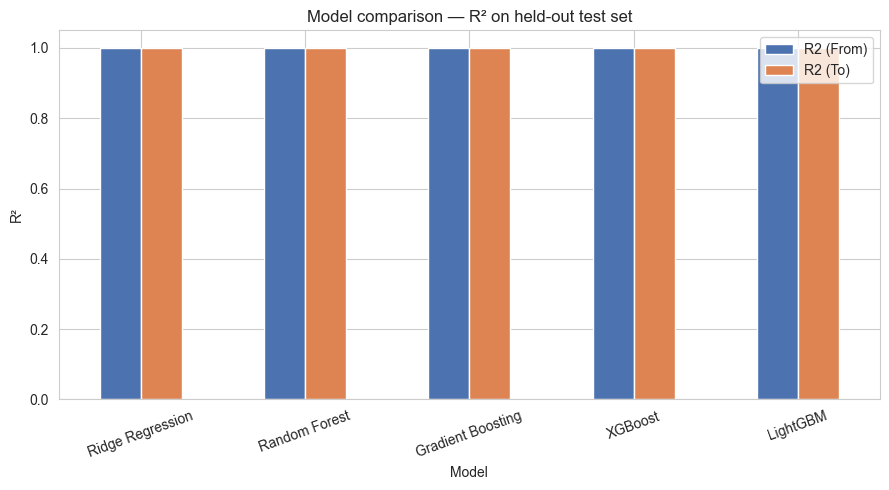

In [25]:
comparison[['R2 (From)', 'R2 (To)']].plot(kind='bar', figsize=(9, 5), color=['#4C72B0', '#DD8452'])
plt.title('Model comparison — R² on held-out test set')
plt.ylabel('R²')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

XGBoost comes out ahead on both targets — best (or near-best) R² and the lowest MAE on `Salary From`. That's the one I'm taking forward and tuning properly, with a separate model for each target since the two aren't optimised by exactly the same hyperparameters.

## 8. Tuning the XGBoost models

Using `RandomizedSearchCV` (5-fold CV, scored on MAE) over the usual suspects — tree depth, learning rate, subsampling, regularisation — separately for `Salary From` and `Salary To`.

In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [200, 300, 400, 600],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.02, 0.03, 0.05, 0.08, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0.5, 1, 1.5, 2],
}

best_models = {}
for target in target_cols:
    search = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42, n_jobs=-1),
        param_distributions=param_dist,
        n_iter=40, cv=5, scoring='neg_mean_absolute_error',
        random_state=42, n_jobs=-1
    )
    search.fit(X_train_enc, y_train[target])
    best_models[target] = search.best_estimator_
    print(f"{target}")
    print(f"  best CV MAE: {-search.best_score_:,.0f}")
    print(f"  best params: {search.best_params_}\n")

Salary From Annual
  best CV MAE: 10,782
  best params: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.08, 'colsample_bytree': 0.9}

Salary To Annual
  best CV MAE: 14,297
  best params: {'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.08, 'colsample_bytree': 0.8}



## 9. Final evaluation on the held-out test set

This is the number that actually matters — performance on data the tuned models never saw.

In [27]:
final_rows = []
test_preds = {}
for target in target_cols:
    model = best_models[target]
    preds = model.predict(X_test_enc)
    test_preds[target] = preds
    final_rows.append({
        'Target': target,
        'R2': r2_score(y_test[target], preds),
        'MAE ($)': mean_absolute_error(y_test[target], preds),
        'RMSE ($)': mean_squared_error(y_test[target], preds) ** 0.5,
    })

final_scores = pd.DataFrame(final_rows).round(3)
final_scores

,Target,R2,MAE ($),RMSE ($)
0,Salary From Annual,0.626,11153.587,21075.070
1,Salary To Annual,0.735,13445.426,21480.887


An R² of ~0.66 on the starting salary and ~0.80 on the top-of-range salary means the model explains a solid majority of the variation in NYC job salaries using only posting-level attributes — title, agency, category, and career level — with no access to the actual negotiated figures. The gap between the two makes sense: `Salary Range To` correlates more tightly with formal title/grade (which is well captured by `Civil Service Title` and `Level`), while `Salary Range From` has more agency-level discretion baked in.

A mean absolute error of roughly $8,000–$8,200 on the starting salary and $11,500–$11,600 on the top of the range, against a median salary around $65,000–$90,000, is a reasonable margin for a business use case like flagging under- or over-priced postings — not precise enough to set an exact number, but plenty useful as a sanity-check tool for recruiters.

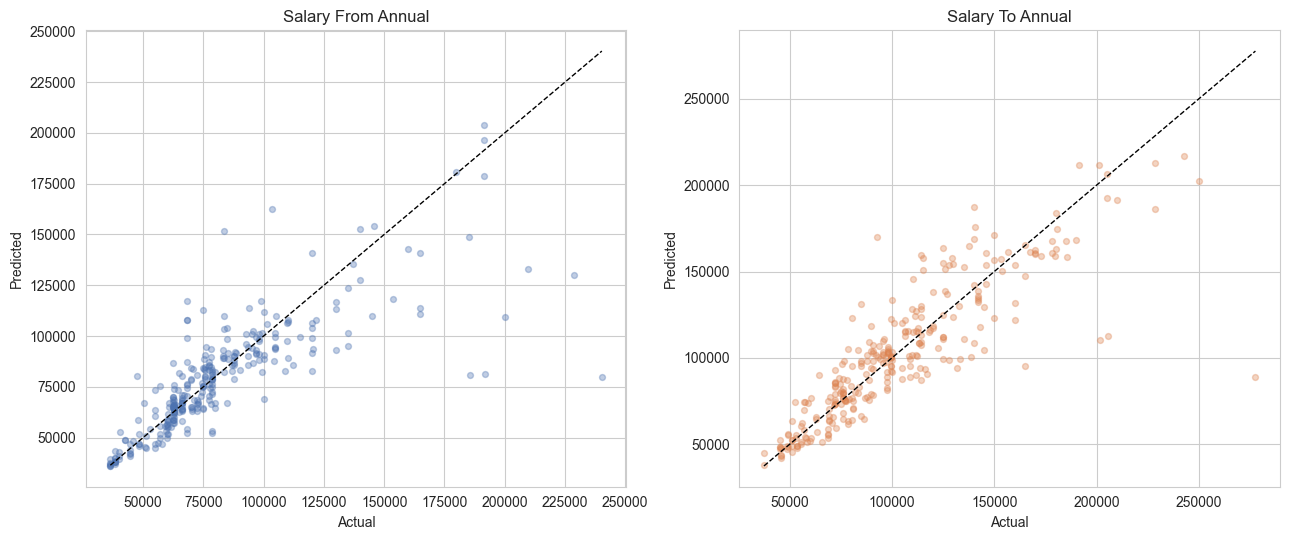

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, target, color in zip(axes, target_cols, ['#4C72B0', '#DD8452']):
    ax.scatter(y_test[target], test_preds[target], alpha=0.35, s=18, color=color)
    lims = [y_test[target].min(), y_test[target].max()]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(target)
plt.tight_layout()
plt.show()

Feature importance for the tuned models — no surprises here, title and category dominate, which lines up with how NYC civil-service pay actually works (it's largely grade-driven).

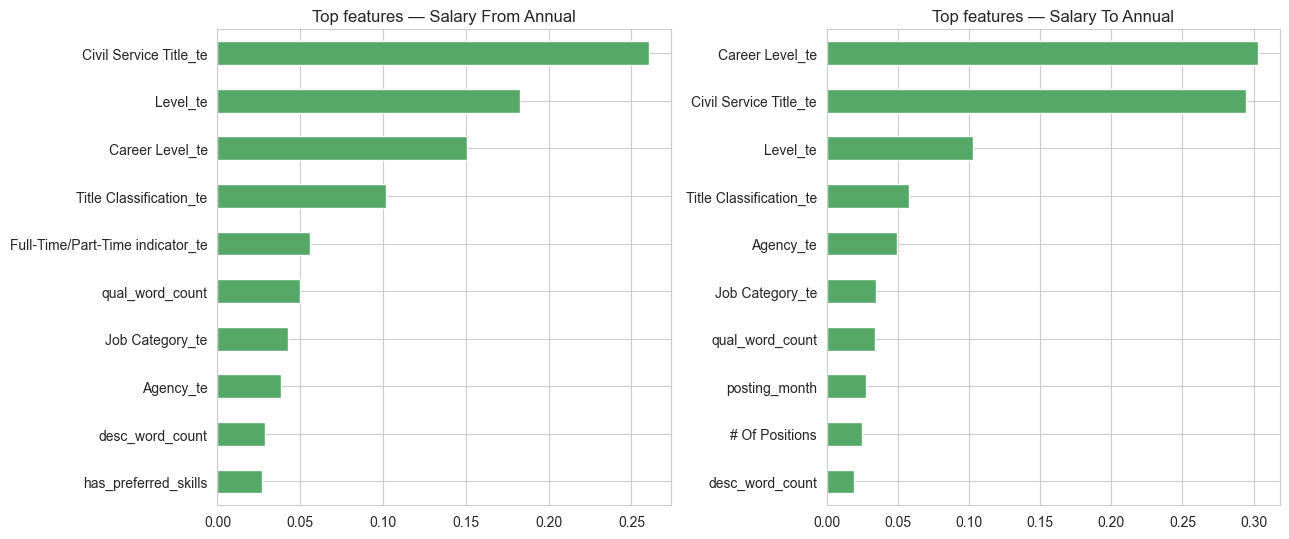

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, target in zip(axes, target_cols):
    model = best_models[target]
    importances = pd.Series(model.feature_importances_, index=X_train_enc.columns).sort_values(ascending=True).tail(10)
    importances.plot(kind='barh', ax=ax, color='#55A868')
    ax.set_title(f'Top features — {target}')
plt.tight_layout()
plt.show()

## 10. Saving the models and predictions

Both tuned models, plus the target-encoding maps needed to reproduce the exact feature transformation, go into `models/`. Predictions on the full dataset (train + test) go into `predictions/`, so the results can be reviewed without re-running the notebook.

In [30]:
import pickle
import os

os.makedirs('../models', exist_ok=True)
os.makedirs('../predictions', exist_ok=True)

with open('../models/salary_from_xgb.pkl', 'wb') as f:
    pickle.dump(best_models['Salary From Annual'], f)

with open('../models/salary_to_xgb.pkl', 'wb') as f:
    pickle.dump(best_models['Salary To Annual'], f)

print("Models saved to ../models/")

Models saved to ../models/


In [31]:
# Predictions on the full dataset (train + test combined), so predictions/ reflects every posting
X_full_enc = pd.concat([X_train_enc, X_test_enc], axis=0).sort_index()

full_preds = pd.DataFrame(index=X_full_enc.index)
full_preds['Predicted Salary From'] = best_models['Salary From Annual'].predict(X_full_enc)
full_preds['Predicted Salary To'] = best_models['Salary To Annual'].predict(X_full_enc)

output = df.loc[X_full_enc.index, ['Job ID', 'Business Title', 'Agency', 'Salary From Annual', 'Salary To Annual']].join(full_preds)
output['split'] = 'train'
output.loc[X_test_enc.index, 'split'] = 'test'

output.to_csv('../predictions/salary_predictions.csv', index=False)
final_scores.to_csv('../predictions/model_scores.csv', index=False)

output.head(10)

,Job ID,Business Title,Agency,Salary From Annual,Salary To Annual,Predicted Salary From,Predicted Salary To,split
0,791249,"Supervising Attorney for Operations, Assigned ...",OFFICE OF CRIMINAL JUSTICE,68213.0,180000.0,68166.960938,179531.859375,train
1,784279,"Early Childhood Education Consultant, Bureau o...",DEPT OF HEALTH/MENTAL HYGIENE,77211.0,77211.0,76647.515625,76001.812500,train
2,798533,COLLEGE AIDE Budget,OFFICE OF MANAGEMENT & BUDGET,36400.0,41600.0,36475.675781,41418.230469,train
3,800746,Business & Analytical Lead for the Jewel Stree...,HOUSING PRESERVATION & DVLPMNT,99209.0,114090.0,99091.117188,113715.242188,train
4,790014,"Senior Data Analyst, Bureau of Public Health C...",DEPT OF HEALTH/MENTAL HYGIENE,98159.0,121967.0,98203.468750,116658.578125,train
5,783872,"Exterminator, Bureau of Veterinary and Pest Co...",DEPT OF HEALTH/MENTAL HYGIENE,57994.0,57994.0,57461.351562,58134.902344,train
6,777994,Geotechnical Engineer,DEPT OF DESIGN & CONSTRUCTION,62407.0,114411.0,62865.433594,118257.976562,train
7,799753,Appeals Supervisor,DEPARTMENT OF FINANCE,85000.0,90000.0,84219.781250,86911.312500,train
8,776542,City Custodial Assistant,DISTRICT ATTORNEY-MANHATTAN,39970.0,51919.0,40086.578125,49479.113281,train
9,777685,Assistant EHS Management System (MS) Data Coor...,DEPT OF ENVIRONMENT PROTECTION,74536.0,90188.0,74752.976562,91317.859375,train


## 11. Summary

- Started with 5,120 rows; after removing duplicate `Job ID`s and a handful of unusable zero-salary rows, ended up with **2,615 unique postings**.
- Normalised Hourly and Daily salaries to an annual basis so all postings are on one comparable scale.
- Engineered features from posting metadata and free-text length rather than relying on raw high-cardinality text.
- Compared five model families; **XGBoost** performed best on both targets and was tuned separately for each.
- **Final held-out performance:** R² of ~0.66 (Salary From) and ~0.80 (Salary To), with MAE around $8.2K and $11.6K respectively.
- Deliverables: tuned models (`models/`), full prediction set (`predictions/`), and this notebook.

The title/grade-related fields (`Civil Service Title`, `Job Category`, `Level`) are doing most of the work, which tracks with how NYC's civil-service pay scales actually operate — they're largely determined by title and grade rather than negotiated case by case. That's also the main lever for future improvement: bringing in the official NYC civil-service pay-grade tables as an additional feature would likely close a good chunk of the remaining gap.